In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import ast
import seaborn as sns

df=pd.read_csv(r"C:\Users\SAMA\Downloads\data_jobs.csv")

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

def clean(skills):
    
    if pd.notna(skills):
        
        return ast.literal_eval(skills)
    
    else :
        
        return skills
    
df['job_skills']=df['job_skills'].apply(clean)  

In [2]:
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()
df_DA_US['job_posted_month']=df_DA_US['job_posted_date'].dt.month
df_DA_US_explo=df_DA_US.explode('job_skills')

In [3]:
df_totals=df_DA_US_explo.groupby(['job_posted_month']).size()

In [4]:
df_pivot=df_DA_US_explo.pivot_table(index='job_posted_month',columns='job_skills',aggfunc='size',fill_value=0)

In [6]:
df_percent=df_pivot.div(df_totals/100,axis=0)

In [18]:
top_5=df_pivot.sum(axis=0).sort_values(ascending=False).head(5).index


In [25]:
df_percent.reset_index(inplace=True)
df_percent['month_name']=df_percent['job_posted_month'].apply(lambda x : pd.to_datetime(x,format='%m').strftime('%b'))
df_percent.set_index('month_name',inplace=True)
df_percent.drop('job_posted_month',axis=1,inplace=True)

In [26]:
df_plot=df_percent[top_5]

In [1]:
from matplotlib.ticker import PercentFormatter


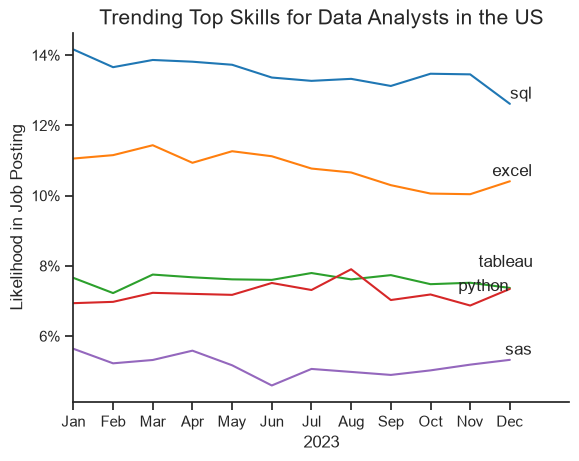

In [64]:

sns.set_theme(style='ticks')
sns.lineplot(df_plot, 
             dashes=False,
             palette='tab10')

texts = []

for i in range(5):
    texts.append(
        plt.text(
            11,
            df_plot.iloc[-1, i],
            df_plot.columns[i]
        )
    )

adjust_text(texts)

plt.xlim(0, 12.5)

plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

sns.despine()
plt.title('Trending Top Skills for Data Analysts in the US',fontsize=15)
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()

plt.show()